In [1]:
import numpy as np
from scipy.special import comb
from scipy.integrate import *
from scipy.linalg import pinv, pinvh, expm

from opt_einsum import contract, contract_expression

import jax.numpy as jnp
from jax import jit
from functools import partial

from integrators import *

import matplotlib.pyplot as plt

from electron_integrals import *

from SemiDirectCI_jax import SemiDirectCI


Define functions

In [2]:
@jit
def Cb_to_y(C, b):
    return jnp.concatenate([C.flatten(), b.flatten()])

@partial(jit, static_argnums=(1,2,3))
def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_slater_dets):
    C, b = jnp.split(y, [num_slater_dets])
    b = jnp.reshape(b, (num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

@jit
def gram_schmidt(b):
    b = jnp.divide(b, jnp.sqrt(contract('ij, ij -> j', b.conj(), b, backend='jax')))
    for i in range(b.shape[1]):
        orto_adjustment = 0
        for j in range(0, i):
            orto_adjustment += jnp.dot(b[:, i], b[:, j])*b[:, j]

        b.at[:,i].add(-orto_adjustment)

    return b

@jit
def overlap_ortnorm(b):
    b = jnp.divide(b, jnp.sqrt(contract('ij, ij -> j', b.conj(), b, backend='jax')))
    u, _, vh = jnp.linalg.svd(b, full_matrices=False)
    return u@vh

@jit
def normalize_C(C):
    return jnp.divide(C, jnp.sqrt(C.T.conj()@C))

@partial(jit, static_argnums=(0,5))
def get_E(dCI, h, g, b, C, C_shape):
    bc = b.conj()
    h_1 = contract('jm, ij -> im', b, h, backend='jax')
    h_2 = contract('in, im -> nm', bc, h_1, backend='jax')

    g_2 = contract('jq, ls, ijkl -> iqks', bc, b, g, backend='jax')
    g_3 = contract('kr, iqks -> iqrs', b, g_2, backend='jax')
    g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')

    return dCI.calculate_energy(jnp.reshape(C, C_shape), h_2, g_4)

Define number of electrons and orbitals

In [59]:
# Number of spatial orbitals
num_spatial_orbitals = 10
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 1

Calculate electron integrals

In [60]:
## "Standard"
# x_max = 10
# num_points = 1001
# x = np.linspace(-x_max,x_max,num_points)
# pot = HOPotential()

## Zhangellini
x = np.linspace(-10, 10, 201)
pot = HOPotential(0.25)

spf, h = get_spf_and_diag_h(num_spatial_orbitals, x, pot)
g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.25) # 0.25 in Zhangellini

#g = np.zeros_like(g)

# Sanity test, due to symmetry in g this should be zero:
np.testing.assert_almost_equal(0, -g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [106]:
num_mctdhf_orbitals = 2
num_mctdhf_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
num_mctdhf_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
num_mctdhf_dets = num_mctdhf_alpha_dets*num_mctdhf_beta_dets
C_shape = (num_mctdhf_alpha_dets, num_mctdhf_beta_dets)


# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spatial_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(jnp.complex64)

#print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_alpha_dets*num_mctdhf_beta_dets).astype(jnp.complex64)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

#C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
#C_init[0] = 1

#print(C_init)

## Contraction time tests

In [6]:
%%timeit
h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
h_3 = contract('in, nm -> im', b_init, h_2)

g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = contract('ip, pqrs -> iqrs', b_init, g_4)

978 µs ± 127 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
%%timeit
h_1 = np.einsum('jm, ij -> im', b_init, h)
h_2 = np.einsum('in, im -> nm', b_init.conj(), h_1)
h_3 = np.einsum('in, nm -> im', b_init, h_2)

g_2 = np.einsum('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = np.einsum('kr, iqks -> iqrs', b_init, g_2)
g_4 = np.einsum('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = np.einsum('ip, pqrs -> iqrs', b_init, g_4)

In [ ]:
eh1 = contract_expression('jm, ij -> im', b_init.shape, h.shape)
eh2 = contract_expression('in, im -> nm', b_init.shape, (num_spatial_orbitals, num_mctdhf_orbitals))
eh3 = contract_expression('in, nm -> im', b_init.shape, (num_mctdhf_orbitals,)*2)

eg2 = contract_expression('jq, ls, ijkl -> iqks', b_init.shape, b_init.shape, g.shape)
eg3 = contract_expression('kr, iqks -> iqrs', b_init.shape, (num_spatial_orbitals,num_mctdhf_orbitals,)*2)
eg4 = contract_expression('ip, iqrs -> pqrs', b_init.shape, (num_spatial_orbitals,)+(num_mctdhf_orbitals,)*3)
eg5 = contract_expression('ip, pqrs -> iqrs', b_init.shape, (num_mctdhf_orbitals,)*4)

In [ ]:
%%timeit
h_1 = eh1(b_init, h)
h_2 = eh2(b_init.conj(), h_1)
h_3 = eh3(b_init, h_2)

g_2 = eg2(b_init.conj(), b_init, g)
g_3 = eg3(b_init, g_2)
g_4 = eg4(b_init.conj(), g_3)
g_5 = eg5(b_init, g_4)


## MCTDHF with JAX

Define callable class for the differential equations

In [107]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    @partial(jit, static_argnums=0)
    def __call__(self, t, y):
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h, backend='jax')
        h_2 = contract('in, im -> nm', bc, h_1, backend='jax')
        h_3 = contract('in, nm -> im', b, h_2, backend='jax')

        g_2 = contract('jq, ls, ijkl -> iqks', bc, b, self.g, backend='jax')
        g_3 = contract('kr, iqks -> iqrs', b, g_2, backend='jax')
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')
        g_5 = contract('ip, pqrs -> iqrs', b, g_4, backend='jax')

        D, d = self.dCI.get_RDMs(jnp.reshape(C, self.C_shape))
        D_inv = jnp.linalg.pinv(D)
        ## Regularize?
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        #D_inv = jnp.linalg.pinv(D_reg)
      
        b_dot = -(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5, backend='jax'))

        sigma = self.dCI.get_sigma(jnp.reshape(C, self.C_shape), h_2, g_4).flatten()
        C_dot = -sigma

        return Cb_to_y(C_dot, b_dot)

### Scipy integrator

In [ ]:
dtype = jnp.complex64
mctdhf_fun = MCDTHF_imaginary_time(jnp.array(h, dtype), jnp.array(g, dtype),
                                   num_mctdhf_orbitals, num_spatial_orbitals, 
                                   num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(jnp.array(C_init, dtype), jnp.array(b_init, dtype))
#y_init = Cb_to_y(C_f, b_f)


Cs = [C_init]
bs = [b_init]

h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)

dCI = SemiDirectCI(num_mctdhf_orbitals, num_alpha_electrons, num_beta_electrons)

E_init = dCI.calculate_energy(C_init.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)
Es = [E_init]

t_init = 0
t_final = 5.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-3)
solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    # Normalize every step during imaginary time prop
    C = normalize_C(C)
    #b = gram_schmidt(b)
    b = overlap_ortnorm(b)
    
    E = get_E(dCI, h, g, b, C, C_shape)    

    Es.append(E)
    Cs.append(C)
    bs.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))
    
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
t = np.linspace(0, solver.t, len(Es))


### Øyvind integrator

In [112]:
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons)

dt = 1e-2
num_steps = 5000
rk4 = get_runge_kutta_4_solver(mctdhf_fun, dt)

y = Cb_to_y(jnp.array(C_init), jnp.array(b_init))

Cs = [C_init]
bs = [b_init]

h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)

dCI = SemiDirectCI(num_mctdhf_orbitals, num_alpha_electrons, num_beta_electrons)

E_init = dCI.calculate_energy(C_init.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)
Es = [E_init]

normalize = True

t = 0
for i in range(num_steps):
    # t, y = rk4(t, y)
    # C, b = y_to_Cb(y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    
    # # # Normalize every step during imaginary time prop
    # if normalize:
    #     C = normalize_C(C)
    #     # #b = gram_schmidt(b)
    #     b = overlap_ortnorm(b)

    # E = get_E(dCI, h, g, b, C, C_shape)

    t, y, E, C, b = step(t,y, normalize)

    Es.append(E)
    Cs.append(C)
    bs.append(b)

    #y = Cb_to_y(C, b)


C_f, b_f = y_to_Cb(y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
t = np.linspace(0, dt*num_steps, len(Cs))

In [111]:
@partial(jit, static_argnums=2)
def step(t,y, normalize):
    t, y = rk4(t, y)
    C, b = y_to_Cb(y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    
    if normalize:
        # Normalize every step during imaginary time prop
        C = normalize_C(C)
        #b = gram_schmidt(b)
        b = overlap_ortnorm(b)

    E = get_E(dCI, h, g, b, C, C_shape)
    y = Cb_to_y(C, b)

    return t, y, E, C, b


## Plots

Final energy: (0.8534326553344727+0j)
Max overlap coeff (ideally zero): 2.384185791015625e-07


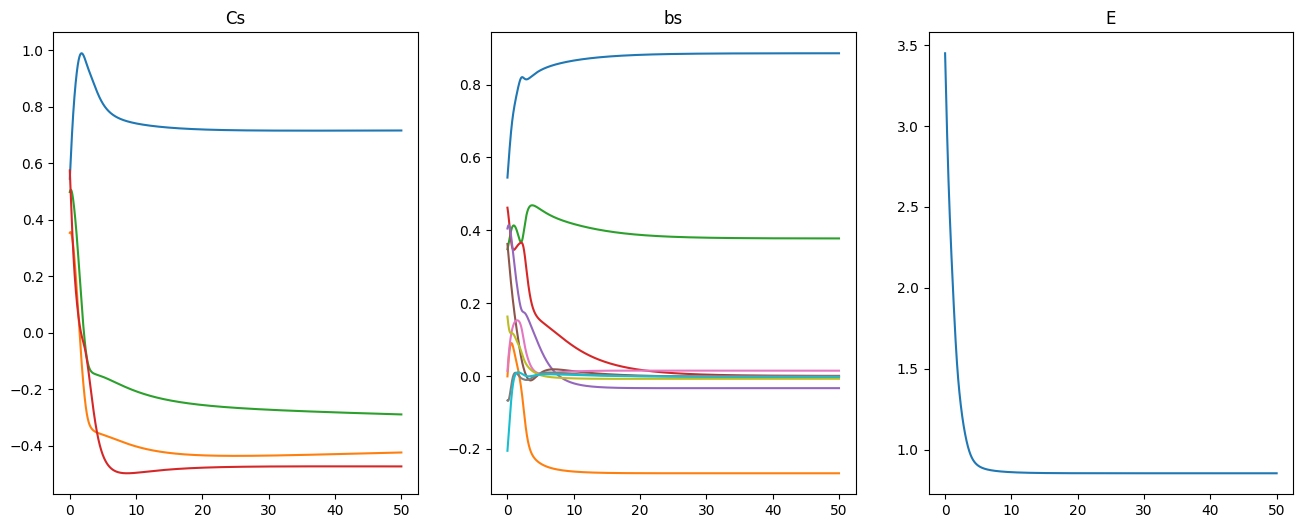

In [113]:
#print(f"Final b =\n{b_f}")
#print(f"Final C =\n{C_f}")
#print(f"Energy: {Es[-1]}")
#print(f"Energy deviation =\n{Es[-1]-E_exact}")
print(f"Final energy: {Es[-1]}")

#print(f"Overlap matrix for final b:\n{b_f.T@b_f}")
print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")


b_arr = np.array(bs)
Es = np.array(Es)
Cs = np.array(Cs)

fig, axs = plt.subplots(1, 3, figsize=(16,6))
axs[0].plot(t, np.real(Cs))
axs[0].set_title('Cs')
axs[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
axs[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es), 'k--')
axs[2].plot(t, np.real(Es))
axs[2].set_title('E')

# for ax in axs:
#     ax.set_xlim(right=t_final)

plt.show()

In [65]:
D = dCI.get_1p_RDM(C_f.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets))

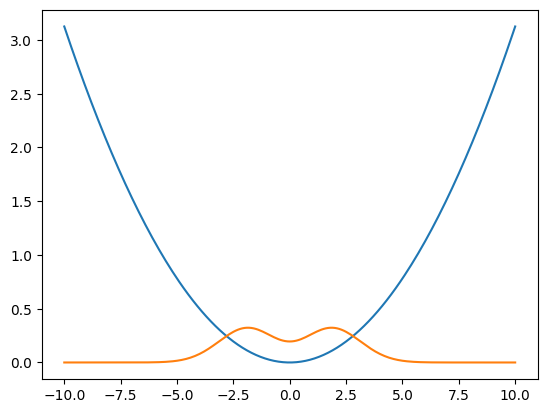

In [66]:
plt.plot(x, pot(x))
plt.plot(x, np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf)))
plt.show()

In [67]:
class MCDTHF:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    @partial(jit, static_argnums=0)
    def __call__(self, t, y):
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h(t), backend='jax')
        h_2 = contract('in, im -> nm', bc, h_1, backend='jax')
        h_3 = contract('in, nm -> im', b, h_2, backend='jax')

        g_2 = contract('jq, ls, ijkl -> iqks', bc, b, self.g, backend='jax')
        g_3 = contract('kr, iqks -> iqrs', b, g_2, backend='jax')
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')
        g_5 = contract('ip, pqrs -> iqrs', b, g_4, backend='jax')

        D, d = self.dCI.get_RDMs(jnp.reshape(C, self.C_shape))
        #D_inv = np.linalg.pinv(D)
        # Regularize
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        D_inv = jnp.linalg.pinv(D)#_reg)
        #D_inv = pinvh(D_reg)
      
        b_dot = -1j*(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5, backend='jax'))

        #sigma = self.dCI.get_sigma_equal_spins(C.reshape(self.C_shape)).flatten()
        sigma = self.dCI.get_sigma(jnp.reshape(C, self.C_shape), h_2, g_4).flatten()

        ## "Renormalization" from (127) in Beck et al. rewritten to direct CI
        #E = self.dCI.calculate_energy_from_RDMs(D,d)
        #C_dot = -(sigma-E*C) 

        C_dot = -1j*sigma

        return Cb_to_y(C_dot, b_dot)

In [68]:
ht = (x[1]-x[0])*contract('ij, j, kj -> ik', spf.conj(), x, spf)

@jit
def h_t(t):
    return h+ht*jnp.sin(2*t)

### Scipy integrator

In [13]:
dtype = jnp.complex64
mctdhf_fun = MCDTHF(h_t, jnp.array(g, dtype),
                    num_mctdhf_orbitals, num_spatial_orbitals, 
                    num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(C_f, b_f)

Cs_rt = [C_f]
bs_rt = [b_f]

Es_rt = [Es[-1]]

t_init = 0
t_final = 3.0

t_final = 4*2*np.pi/(0.25*8)

solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    
    # Is normalizing necessary here?
    C = normalize_C(C)
    #b = gram_schmidt(b)
    b = overlap_ortnorm(b)
 
    E = get_E(dCI, h, g, b, C, C_shape)

    Es_rt.append(E)
    Cs_rt.append(C)
    bs_rt.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))
    
t = np.linspace(t_init, solver.t, len(Cs_rt))

### Øyvind integrator

In [69]:
mctdhf_fun = MCDTHF(h_t, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons)

dt = 1e-2
#num_steps = 400

num_steps = int(4*2*np.pi/(0.25*8*dt))

rk4 = get_runge_kutta_4_solver(mctdhf_fun, dt)

y = Cb_to_y(C_f, b_f)

Cs_rt = [C_f]
bs_rt = [b_f]

Es_rt = [Es[-1]]

t=0
for i in range(num_steps):
    t, y = rk4(t, y)
    C, b = y_to_Cb(y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    
    # Is normalizing necessary here?
    #C = normalize_C(C)
    #b = gram_schmidt(b)
    #b = overlap_ortnorm(b)
 
    E = get_E(dCI, h_t(t), g, b, C, C_shape)

    Es_rt.append(E)
    Cs_rt.append(C)
    bs_rt.append(b)

    y = Cb_to_y(C, b)

t = np.linspace(0, dt*num_steps, len(Cs_rt))

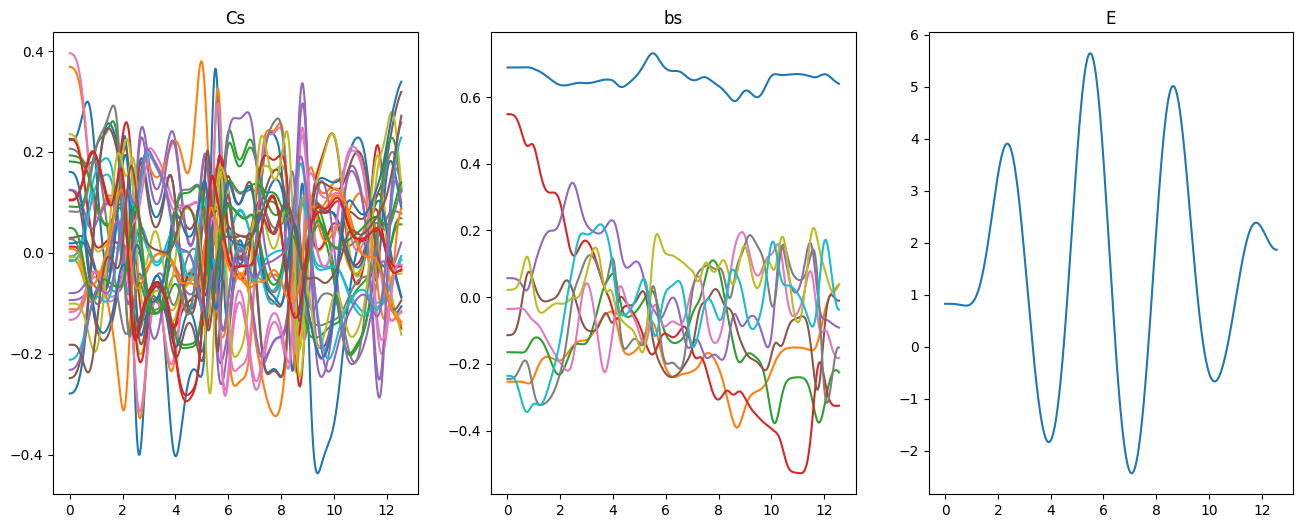

In [70]:
Es_rt = np.array(Es_rt)
Cs_rt = np.array(Cs_rt)
b_arr = np.array(bs_rt)


fig, ax = plt.subplots(1, 3, figsize=(16,6))
ax[0].plot(t, np.real(Cs_rt))
ax[0].set_title('Cs')
ax[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
ax[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es_rt), 'k--')
ax[2].plot(t, np.real(Es_rt))
ax[2].set_title('E')
plt.show()

In [71]:
I_alpha = dCI.get_slater_dets(num_mctdhf_orbitals, num_alpha_electrons)
def calculate_overlap_comp(b1,C1,b2,C2):
    S = np.zeros(C1.shape, np.complex64)
    for i, I_a in enumerate(I_alpha):
        for j, J_a in enumerate(I_alpha):
            I_inds = [index for index, element in enumerate(I_a) if element==1]
            J_inds = [index for index, element in enumerate(J_a) if element==1]
            s = np.einsum('ik,jk->ij', b1[I_inds,:], b2[J_inds,:])
            S[i,j] = np.linalg.det(s)

    overlap = 0
    for ia in range(num_mctdhf_alpha_dets):
        for ib in range(num_mctdhf_beta_dets):
            for ja in range(num_mctdhf_alpha_dets):
                for jb in range(num_mctdhf_beta_dets):
                    overlap += C1[ia,ib].conj()*C2[ja,jb]*S[ia,ja]*S[ib,jb]

    return overlap

In [72]:
I_alpha = dCI.get_slater_dets(num_mctdhf_orbitals, num_alpha_electrons)
def calculate_overlap_comp(b1,C1,b2,C2):
    S = np.zeros(C1.shape, np.complex64)
    for i, I_a in enumerate(I_alpha):
        for j, J_a in enumerate(I_alpha):
            s = contract('ik,jk->ij', b1[I_a,:], b2[J_a,:])
            S[i,j] = np.linalg.det(s)
    return contract('ik,jl,ij,kl',C1.conj(),C2,S,S)

In [73]:
I_alpha = dCI.get_slater_dets(num_mctdhf_orbitals, num_alpha_electrons)
I_beta = dCI.get_slater_dets(num_mctdhf_orbitals, num_beta_electrons)

@jit
def calculate_overlap(b2,C2,b1=b_f,C1=C_f.reshape(C_shape), I_alpha=I_alpha):
    S = jnp.zeros(C1.shape, np.complex64)
    for i, I_a in enumerate(I_alpha):
        for j, J_a in enumerate(I_alpha):
            s = contract('ki,kj->ij', b1[:,I_a], b2[:,J_a], backend='jax')
            S = S.at[i,j].set(jnp.linalg.det(s))
    return contract('ik,jl,ij,kl',C1.conj(),C2,S,S, backend='jax')

@jit
def calculate_overlap_2(b2,C2,b1=b_f,C1=C_f.reshape(C_shape), I_alpha=I_alpha, I_beta=I_beta):
    S_a = jnp.zeros(C1.shape, np.complex64)
    for i, I_a in enumerate(I_alpha):
        for j, J_a in enumerate(I_alpha):
            s = contract('ki,kj->ij', b1[:,I_a], b2[:,J_a], backend='jax')
            S_a = S_a.at[i,j].set(jnp.linalg.det(s))
    
    S_b = jnp.zeros(C1.shape, np.complex64)
    for i, I_b in enumerate(I_beta):
        for j, J_b in enumerate(I_beta):
            s = contract('ki,kj->ij', b1[:,I_b], b2[:,J_b], backend='jax')
            S_b = S_b.at[i,j].set(jnp.linalg.det(s))

    #return S_a, S_b
    return contract('ik,jl,ij,kl',C1.conj(),C2,S_a,S_b, backend='jax')

@jit
def calculate_overlap_3(b2,C2,b1=b_f,C1=C_f.reshape(C_shape), I_alpha=I_alpha, I_beta=I_beta):
    s_a = contract('ai,ki,kj,bj->abij', I_alpha, b1, b2, I_alpha, backend='jax')
    s_a = s_a[jnp.nonzero(s_a, size=(num_mctdhf_alpha_dets*num_alpha_electrons)**2)]
    S_a = jnp.linalg.det(s_a.reshape((num_mctdhf_alpha_dets,)*2+(num_alpha_electrons,)*2))

    s_b = contract('ai,ki,kj,bj->abij', I_beta, b1, b2, I_beta, backend='jax')
    s_b = s_b[jnp.nonzero(s_b, size=(num_mctdhf_beta_dets*num_beta_electrons)**2)]
    S_b = jnp.linalg.det(s_b.reshape((num_mctdhf_beta_dets,)*2+(num_beta_electrons,)*2))

    return contract('ik,jl,ij,kl',C1.conj(),C2,S_a,S_b, backend='jax')

In [18]:
s = jnp.array(contract('ai,ki,kj,bj->abij', I_alpha, b_f, b, I_alpha))
s_1 = s[jnp.nonzero(s, size=900)].reshape(15,15,2,2)
print(jnp.linalg.det(s_1)[0])
s_2 = s[s!=0].reshape(15,15,2,2)
print(np.linalg.det(s_2)[0])


np.testing.assert_allclose(jnp.linalg.det(s_1),np.linalg.det(s_2), rtol=1e-5)

[ 0.05564097-0.08768076j -0.0718984 +0.04044516j  0.00867449-0.04317934j
  0.06664374-0.12305009j  0.02250538+0.02659088j -0.01339854+0.0317864j
  0.00289562+0.13300626j -0.10007043+0.05902171j  0.07082018-0.05589575j
 -0.08616219+0.10104033j  0.16617058-0.11950291j  0.01373765+0.0949892j
 -0.02148804+0.00096553j  0.00567318+0.06125491j  0.1443079 -0.12600617j]
[ 0.05564097-0.08768076j -0.0718984 +0.04044516j  0.00867448-0.04317934j
  0.06664375-0.12305009j  0.02250538+0.02659088j -0.01339855+0.0317864j
  0.00289563+0.13300626j -0.10007043+0.05902171j  0.07082018-0.05589575j
 -0.0861622 +0.10104033j  0.16617057-0.1195029j   0.01373765+0.0949892j
 -0.02148804+0.00096553j  0.00567318+0.06125491j  0.1443079 -0.12600617j]


In [22]:
S_a = np.zeros(C_shape, np.complex64)
for i, I_a in enumerate(I_alpha):
    for j, J_a in enumerate(I_alpha):
        s = contract('ki,kj->ij', b_f[:,I_a], b[:,J_a], backend='jax')
        S_a[i,j] = np.linalg.det(s)

S_b = np.zeros(C_shape, np.complex64)
for i, I_a in enumerate(I_beta):
    for j, J_a in enumerate(I_beta):
        s = contract('ki,kj->ij', b_f[:,I_a], b[:,J_a], backend='jax')
        S_b[i,j] = np.linalg.det(s)

print(s.shape)
print(np.linalg.det(s))
s = contract('i,ki,kj,j->ij', I_a, b_f, b, I_a)
print(s[s != 0].reshape(2,2))
s = contract('ai,ki,kj,bj->abij', I_alpha, b_f, b, I_alpha)
S_2 = np.linalg.det(s[s!=0].reshape(15,15,2,2))
np.testing.assert_almost_equal(S,S_2)

s = jnp.array(contract('ai,ki,kj,bj->abij', I_alpha, b_f, b, I_alpha))
s = s[jnp.nonzero(s, size=900)].reshape(15,15,2,2)


S_2a, S_2b = calculate_overlap_2(b_f,C_f.reshape(C_shape))
S_3a, S_3b = calculate_overlap_3(b_f,C_f.reshape(C_shape))

print(S_2[2])
print(S_2a[2])
print(S_3a[2])

np.testing.assert_allclose(np.array(S_a),np.array(S_3a),1e-5)
np.testing.assert_allclose(np.array(S_b),np.array(S_3b),1e-5)

(2, 2)
(0.36548993+0.0037943372j)
[[0.6081118 +0.10345637j 0.0813783 +0.08790034j]
 [0.01959721+0.22855654j 0.5611161 -0.05580314j]]
[-0.05009298+0.05991663j -0.04702748+0.23198567j -0.11918671-0.01397555j
 -0.26323003-0.08357111j  0.05836391-0.10747053j  0.11452504+0.03808206j
  0.0646755 -0.10980958j  0.08467195-0.01122496j  0.0138601 -0.14285725j
  0.21558556+0.07344172j  0.05647892-0.0522679j   0.0518716 +0.01009387j
  0.03808616-0.07658698j  0.10705899+0.08556513j -0.00203764-0.00276516j]
[ 5.5442804e-08+0.j  1.7287686e-08+0.j  1.0000006e+00+0.j
 -1.9693846e-15+0.j -2.1420419e-08+0.j  2.8841908e-08+0.j
 -9.6545544e-15+0.j -5.3587428e-08+0.j  1.5742633e-07+0.j
 -1.8265734e-15+0.j  6.7028233e-15+0.j -4.7220979e-08+0.j
 -1.3562028e-07+0.j  4.2669840e-15-0.j  1.4701358e-14-0.j]
[-0.05009297+0.05991662j -0.04702749+0.23198569j -0.11918671-0.01397555j
 -0.26323003-0.08357111j  0.05836391-0.10747055j  0.11452505+0.03808205j
  0.06467549-0.10980958j  0.08467194-0.01122496j  0.0138601 -0.1

In [201]:
np.linalg.det(b_f.T@b_f)

(1.0000011+0j)

In [74]:
overlap_c = [calculate_overlap(b, C.reshape(C_shape)) for b,C in zip(b_arr, Cs_rt)]

In [75]:
overlap = [calculate_overlap_3(b, C.reshape(C_shape)) for b,C in zip(b_arr, Cs_rt)]

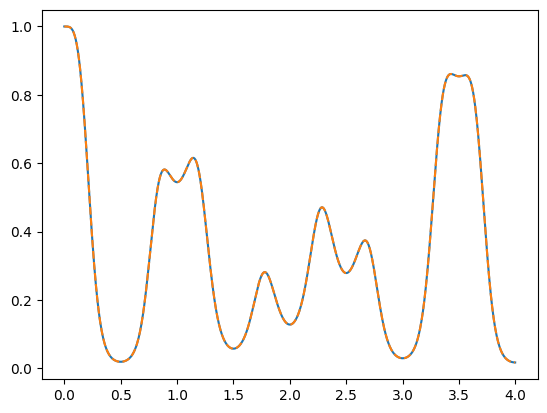

In [76]:
#plt.plot(t*0.25*8/(2*np.pi), np.abs(C_f.T@Cs_rt.T)**2)
#plt.plot(t*0.25*8/(2*np.pi), np.abs(contract('ij, tij -> t', b_f, b_arr))**2)
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap)**2)
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap_c)**2,'--')
#plt.plot(t,overlap_1)
plt.show()

In [95]:
# overlap_1 = np.copy(overlap)
# density_1 = np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf))
# overlap_2 = np.copy(overlap)
# density_2 = np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf))
# overlap_3 = np.copy(overlap)
# density_3 = np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf))
# overlap_4 = np.copy(overlap)
# density_4 = np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf))

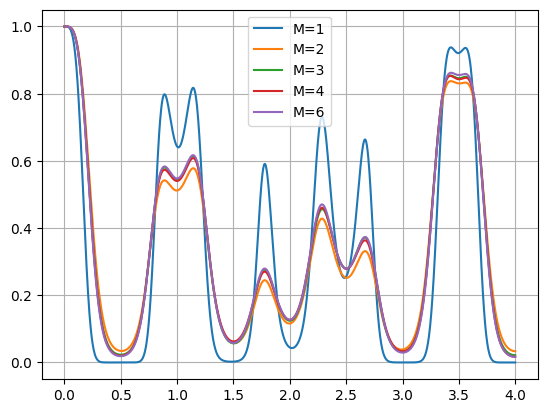

In [115]:
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap_1)**2, label = 'M=1')
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap_2)**2, label = 'M=2')
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap_3)**2, label = 'M=3')
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap_4)**2, label = 'M=4')
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap)**2, label = f'M={num_mctdhf_orbitals}')
plt.plot()
plt.legend()
plt.grid()
plt.show()

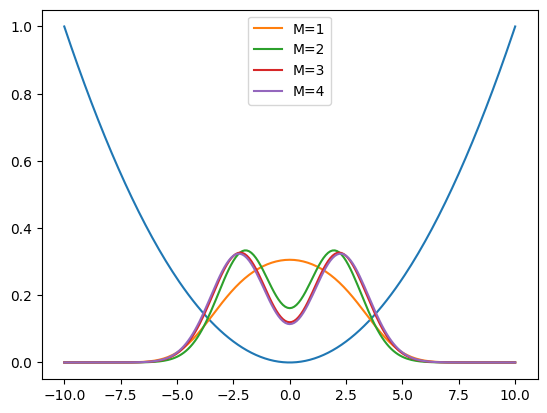

In [100]:
plt.plot(x,pot(x)/np.max(pot(x)))
plt.plot(x,density_1, label = 'M=1')
plt.plot(x,density_2, label = 'M=2')
plt.plot(x,density_3, label = 'M=3')
plt.plot(x,density_4, label = 'M=4')
plt.legend()
plt.show()

In [ ]:
@jit
def calculate_overlap_3(b2,C2,b1=b_f,C1=C_f.reshape(C_shape), I_alpha=I_alpha, I_beta=I_beta):
    s_a = contract('ai,ki,kj,bj->abij', I_alpha, b1, b2, I_alpha, backend='jax')
    s_a = s_a[jnp.nonzero(s_a, size=(num_mctdhf_alpha_dets*num_alpha_electrons)**2)]
    S_a = jnp.linalg.det(s_a.reshape((num_mctdhf_alpha_dets,)*2+(num_alpha_electrons,)*2))

    s_b = contract('ai,ki,kj,bj->abij', I_beta, b1, b2, I_beta, backend='jax')
    s_b = s_b[jnp.nonzero(s_b, size=(num_mctdhf_beta_dets*num_beta_electrons)**2)]
    S_b = jnp.linalg.det(s_b.reshape((num_mctdhf_beta_dets,)*2+(num_beta_electrons,)*2))

    return contract('ik,jl,ij,kl',C1.conj(),C2,S_a,S_b, backend='jax')

In [79]:
class TestClass:
    def __init__(self, a):
        self.a = a 
    
    def func(self):
        return self.a*5

    def __call__(self, b):
        return b*self.func()/5

class SubClass(TestClass):
    def func(self):
        return self.a*10

In [83]:
tc=TestClass(3)
print(tc(2))
sc = SubClass(3)
print(sc(2))

6.0
12.0
